# Notebook 2 — Signal Injection, Matched-Filter SNR, and Time-Frequency Maps
### Detectability-Aware Post-Merger GW Anomaly Screening — Project Notebook 2/6

This notebook loads the noise model and raw L1 blocks from Notebook 1, generates damped-sinusoid
injections at a specified matched-filter SNR, checks the SNR convention, and builds the CQT
representation used by the later notebooks.

**Depends on:** `nb1_artifacts/` (`gps_blocks.json`, `estimated_psd.npz`, and the cached raw L1 blocks).
Run Notebook 1 first if these files are missing.


In [ ]:
# ---------------------------------------------------------------------------
# 0. Installs
# ---------------------------------------------------------------------------
!pip install -q librosa

## 1. Load Notebook 1 artifacts

Load the block layout, operational PSD, and raw noise pools produced by Notebook 1. The whitening
passband and edge padding are kept the same here so this notebook can run independently in Colab.


In [ ]:
# ---------------------------------------------------------------------------
# 1. Imports, config, load Notebook 1 artifacts
# ---------------------------------------------------------------------------
import os
import json
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from google.colab import drive; drive.mount('/content/drive')

SEED = 42
rng = np.random.default_rng(SEED)

NB1_DIR = '/content/drive/MyDrive/gw_postmerger/nb1_artifacts'
OUT_DIR = '/content/drive/MyDrive/gw_postmerger/nb2_artifacts'
os.makedirs(OUT_DIR, exist_ok=True)

assert os.path.isdir(NB1_DIR), f"{NB1_DIR} not found; run Notebook 1 first."

FS = 16384
WINDOW_DUR = 0.1
N_SAMPLES_WINDOW = int(FS * WINDOW_DUR)

# Whitening settings shared with Notebook 1.
F_LOW = 20.0
F_HIGH = 6000.0
EDGE_TRIM_S = 4.0
PAD_SAMPLES = int(round(EDGE_TRIM_S * FS))
LOCAL_SEGMENT_SAMPLES = N_SAMPLES_WINDOW + 2 * PAD_SAMPLES

BLOCKS = json.load(open(os.path.join(NB1_DIR, "gps_blocks.json")))
_psd_npz = np.load(os.path.join(NB1_DIR, "estimated_psd.npz"))
# Load the operational PSD saved by Notebook 1. `psd_raw` is diagnostic only.
psd_freqs, psd_values = _psd_npz["freqs"], _psd_npz["psd"]
assert np.all(np.isfinite(psd_values)) and np.all(psd_values > 0)

_psd_interp = interp1d(psd_freqs, psd_values, bounds_error=False,
                        fill_value=(psd_values[0], psd_values[-1]))

def whiten(data, fs=FS, psd_interp=_psd_interp, f_low=F_LOW, f_high=F_HIGH):
    """Whiten a 1D array with the Notebook 1 PSD inside [f_low, f_high]."""
    assert np.all(np.isfinite(data)), "whiten(): input contains non-finite values."
    n = len(data)
    freqs = np.fft.rfftfreq(n, d=1.0/fs)
    passband = (freqs >= f_low) & (freqs <= f_high)
    asd = np.sqrt(psd_interp(freqs[passband]))
    assert np.all(np.isfinite(asd)) and np.all(asd > 0)
    data_fft = np.fft.rfft(data)
    whitened_fft = np.zeros_like(data_fft)
    whitened_fft[passband] = data_fft[passband] / asd
    out = np.fft.irfft(whitened_fft, n=n)
    assert np.all(np.isfinite(out)), "whiten(): output contains non-finite values."
    return out

raw_noise_pools = {}
for name in ['calib_block', 'train_block', 'test_block']:
    arr = np.load(os.path.join(NB1_DIR, f"raw_{name}_L1.npy"))
    assert np.all(np.isfinite(arr)), f"{name}: loaded raw pool is non-finite!"
    assert len(arr) > LOCAL_SEGMENT_SAMPLES, f"{name}: pool too short for the padded local segment."
    raw_noise_pools[name] = arr
    print(f"{name:12s}: loaded {len(arr)} samples ({len(arr)/FS:.0f}s) of raw noise")

print(f"\nWhitening passband: [{F_LOW}, {F_HIGH}] Hz, edge trim: {EDGE_TRIM_S}s "
      f"({PAD_SAMPLES} samples) per side")


Mounted at /content/drive
calib_block : loaded 16777216 samples (1024s) of raw noise
train_block : loaded 16777216 samples (1024s) of raw noise
test_block  : loaded 16777216 samples (1024s) of raw noise

Whitening passband: [20.0, 6000.0] Hz, edge trim: 4.0s (65536 samples) per side


## 2. Signal generator

Use a single damped sinusoid as the post-merger proxy:

$$h(t) = A\,e^{-t/\tau}\sin(2\pi f_{\rm peak} t + \phi).$$


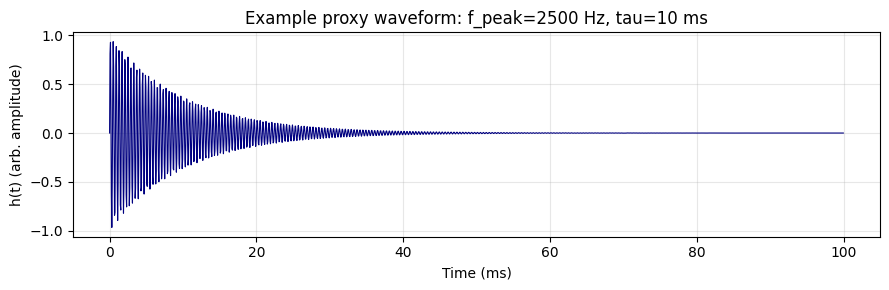

In [ ]:
# ---------------------------------------------------------------------------
# 2. Damped-sinusoid post-merger proxy signal generator
# ---------------------------------------------------------------------------
def generate_signal(f_peak, tau, amplitude=1.0, phi=0.0, fs=FS, n_samples=N_SAMPLES_WINDOW):
    """Generate a damped sinusoid with f_peak in Hz and tau in seconds."""
    t = np.arange(n_samples) / fs
    return amplitude * np.exp(-t / tau) * np.sin(2 * np.pi * f_peak * t + phi)

# Example waveform
_example = generate_signal(f_peak=2500.0, tau=0.010)
plt.figure(figsize=(9, 3))
plt.plot(np.arange(N_SAMPLES_WINDOW) / FS * 1000, _example, color='navy', lw=0.8)
plt.xlabel('Time (ms)'); plt.ylabel('h(t) (arb. amplitude)')
plt.title('Example proxy waveform: f_peak=2500 Hz, tau=10 ms')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 3. Matched-filter SNR

The injection amplitude is set with

$$\rho^2 = 4\int_0^\infty \frac{|\tilde h(f)|^2}{S_n(f)}\,df,$$

using the empirical PSD from Notebook 1 over the same 20–6000 Hz passband as the whitening step.
The discrete Fourier transform is converted to the continuous-transform convention with the
$\Delta t = 1/f_s$ factor.


In [ ]:
# ---------------------------------------------------------------------------
# 3. Matched-filter SNR
# ---------------------------------------------------------------------------
def compute_snr(h_t, psd_interp=_psd_interp, fs=FS, f_low=F_LOW, f_high=F_HIGH):
    """Compute the band-limited matched-filter norm of a time-domain signal."""
    n = len(h_t)
    freqs = np.fft.rfftfreq(n, d=1.0 / fs)
    passband = (freqs >= f_low) & (freqs <= f_high)
    h_fft = np.fft.rfft(h_t) / fs  # discrete -> continuous FT normalization
    df = freqs[1] - freqs[0]
    rho2 = 4.0 * np.sum(np.abs(h_fft[passband])**2 / psd_interp(freqs[passband])) * df
    return np.sqrt(rho2)

def scale_to_snr(h_t, target_snr, psd_interp=_psd_interp, fs=FS):
    """Rescale h_t to the requested matched-filter SNR."""
    base = compute_snr(h_t, psd_interp=psd_interp, fs=fs)
    assert base > 0, "compute_snr returned a non-positive value."
    return h_t * (target_snr / base)

# Scaling check
h_test = generate_signal(f_peak=2500.0, tau=0.010)
snr_base = compute_snr(h_test)
snr_2x = compute_snr(2.0 * h_test)
print(f"compute_snr(h)      = {snr_base:.4f}")
print(f"compute_snr(2h)     = {snr_2x:.4f}")
assert np.isclose(snr_2x, 2.0 * snr_base, rtol=1e-6), "compute_snr failed the amplitude-linearity check."

h_scaled = scale_to_snr(h_test, target_snr=12.0)
recovered = compute_snr(h_scaled)
print(f"scale_to_snr target=12.0 -> compute_snr(scaled) = {recovered:.4f}")
assert np.isclose(recovered, 12.0, rtol=1e-6), "scale_to_snr failed the consistency check."
print("SNR scaling check passed.")


compute_snr(h)      = 1792033621933527924736.0000
compute_snr(2h)     = 3584067243867055849472.0000
scale_to_snr target=12.0 -> compute_snr(scaled) = 12.0000
SNR scaling check passed.


## 4. Injection

For each injection, draw a padded segment from the requested noise block, place the signal in the
central 100 ms, whiten the full padded segment, and crop the center. This keeps whitening transients
away from the analysis window.

Each block draws only from its own cached noise pool.


In [ ]:
# ---------------------------------------------------------------------------
# 4. Injection: pad -> inject -> whiten -> crop
# ---------------------------------------------------------------------------
def inject_and_whiten(block_name, f_peak, tau, target_snr, rng=rng,
                       fs=FS, window_samples=N_SAMPLES_WINDOW, pad_samples=PAD_SAMPLES):
    """Inject into the center of a padded noise segment, whiten it, and return the center window."""
    pool = raw_noise_pools[block_name]
    local_len = window_samples + 2 * pad_samples
    start_idx = rng.integers(0, len(pool) - local_len)
    local_noise = pool[start_idx: start_idx + local_len].astype(np.float64)
    local_noise = local_noise - local_noise.mean()

    h_t = generate_signal(f_peak, tau, fs=fs, n_samples=window_samples)
    h_scaled = scale_to_snr(h_t, target_snr, fs=fs)

    injected_local = local_noise.copy()
    injected_local[pad_samples: pad_samples + window_samples] += h_scaled

    whitened_local = whiten(injected_local, fs=fs)
    interior = whitened_local[pad_samples: pad_samples + window_samples]
    assert len(interior) == window_samples
    assert np.all(np.isfinite(interior))
    return interior, h_scaled, start_idx

def make_noise_only_window(block_name, rng=rng, fs=FS, window_samples=N_SAMPLES_WINDOW,
                            pad_samples=PAD_SAMPLES):
    """Return a noise-only window using the same padded whitening path."""
    pool = raw_noise_pools[block_name]
    local_len = window_samples + 2 * pad_samples
    start_idx = rng.integers(0, len(pool) - local_len)
    local_noise = pool[start_idx: start_idx + local_len].astype(np.float64)
    local_noise = local_noise - local_noise.mean()
    whitened_local = whiten(local_noise, fs=fs)
    interior = whitened_local[pad_samples: pad_samples + window_samples]
    assert np.all(np.isfinite(interior))
    return interior, start_idx


## 5. Matched-filter SNR checks

Three checks separate the SNR normalization from the behavior of real detector noise:

- **Test A:** recover a known SNR in synthetic Gaussian noise generated from the same PSD convention.
- **Test B:** repeat the recovery calculation on real `calib_block` noise as a diagnostic.
- **Test C:** run the actual padded injection/whitening path and check finite values, variance, and
  edge behavior.


### Test A — synthetic Gaussian noise

Generate Gaussian noise with the same one-sided PSD convention used by `compute_snr`. For an
$rFFT$ of length $N$, the independent positive-frequency bins satisfy

$$E[|\mathrm{FFT}(n)[k]|^2] = \frac{f_s N}{2} S_n(f_k).$$

The recovered SNR should therefore be centered near the target with a spread near one.


=== Test A: synthetic Gaussian noise (matched to compute_snr's own PSD convention) ===
Target SNR: 12.0
mean=12.055  std=1.042  median=12.038  robust_std=1.015
quantiles: 1%=9.76  5%=10.28  50%=12.04  95%=13.83  99%=14.39


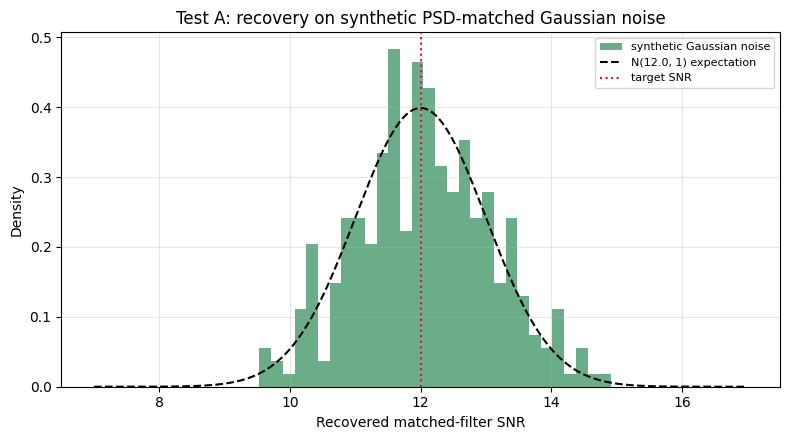


Test A passed.


In [ ]:
# ---------------------------------------------------------------------------
# Test A: synthetic Gaussian noise matched to compute_snr's own PSD convention
# ---------------------------------------------------------------------------
def generate_gaussian_colored_noise(psd_interp=_psd_interp, fs=FS, n_samples=N_SAMPLES_WINDOW,
                                     f_low=F_LOW, f_high=F_HIGH, rng=rng):
    """Generate Gaussian noise with the one-sided PSD used by the SNR calculation."""
    N = n_samples
    freqs = np.fft.rfftfreq(N, d=1.0 / fs)
    passband = (freqs >= f_low) & (freqs <= f_high)
    raw_fft = np.zeros(len(freqs), dtype=complex)
    S = psd_interp(freqs[passband])
    sigma = 0.5 * np.sqrt(fs * N * S)  # std of real and imag parts separately
    raw_fft[passband] = rng.normal(0.0, sigma) + 1j * rng.normal(0.0, sigma)
    noise = np.fft.irfft(raw_fft, n=N)
    return noise

def matched_filter_snr(data, template, psd_interp=_psd_interp, fs=FS, f_low=F_LOW, f_high=F_HIGH):
    n = len(data)
    assert len(template) == n
    freqs = np.fft.rfftfreq(n, d=1.0 / fs)
    passband = (freqs >= f_low) & (freqs <= f_high)
    df = freqs[1] - freqs[0]
    data_fft = np.fft.rfft(data) / fs
    temp_fft = np.fft.rfft(template) / fs
    inner = 4.0 * np.sum((data_fft[passband] * np.conj(temp_fft[passband])).real
                          / psd_interp(freqs[passband])) * df
    norm = compute_snr(template, psd_interp=psd_interp, fs=fs)
    return inner / norm

def recovery_trial_stats(recovered, target_snr):
    recovered = np.array(recovered)
    median = np.median(recovered)
    q25, q75 = np.percentile(recovered, [25, 75])
    robust_std = (q75 - q25) / 1.349
    return {
        "mean": recovered.mean(), "std": recovered.std(),
        "median": median, "robust_std": robust_std,
        "q01": np.percentile(recovered, 1), "q05": np.percentile(recovered, 5),
        "q50": median, "q95": np.percentile(recovered, 95), "q99": np.percentile(recovered, 99),
    }

N_TRIALS_A = 300
TARGET_SNR = 12.0
tau_test = 0.010

recovered_gaussian = []
for _ in range(N_TRIALS_A):
    synth_noise = generate_gaussian_colored_noise()
    f_peak_trial = rng.uniform(1500.0, 4000.0)
    h_t = generate_signal(f_peak_trial, tau_test)
    h_scaled = scale_to_snr(h_t, TARGET_SNR)
    data_window = synth_noise + h_scaled
    recovered_gaussian.append(matched_filter_snr(data_window, h_scaled))

stats_A = recovery_trial_stats(recovered_gaussian, TARGET_SNR)
print("=== Test A: synthetic Gaussian noise (matched to compute_snr's own PSD convention) ===")
print(f"Target SNR: {TARGET_SNR}")
print(f"mean={stats_A['mean']:.3f}  std={stats_A['std']:.3f}  median={stats_A['median']:.3f}  "
      f"robust_std={stats_A['robust_std']:.3f}")
print(f"quantiles: 1%={stats_A['q01']:.2f}  5%={stats_A['q05']:.2f}  50%={stats_A['q50']:.2f}  "
      f"95%={stats_A['q95']:.2f}  99%={stats_A['q99']:.2f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(recovered_gaussian, bins=30, alpha=0.7, color='seagreen', density=True,
        label='synthetic Gaussian noise')
xs = np.linspace(TARGET_SNR - 5, TARGET_SNR + 5, 200)
from scipy import stats as _stats
ax.plot(xs, _stats.norm.pdf(xs, loc=TARGET_SNR, scale=1.0), color='k', ls='--',
        label=f'N({TARGET_SNR}, 1) expectation')
ax.axvline(TARGET_SNR, color='crimson', ls=':', label='target SNR')
ax.set_xlabel('Recovered matched-filter SNR'); ax.set_ylabel('Density')
ax.set_title('Test A: recovery on synthetic PSD-matched Gaussian noise')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'plot_testA_gaussian_snr_recovery.pdf'))
plt.show()

# Under the matched Gaussian model, the recovered SNR should be centered at the target with unit spread.
assert abs(stats_A['median'] - TARGET_SNR) < 0.5, (
    f"Test A: median recovered SNR {stats_A['median']:.2f} differs from target {TARGET_SNR}."
)
assert 0.7 < stats_A['robust_std'] < 1.4, (
    f"Test A: robust std {stats_A['robust_std']:.2f} is outside the expected range."
)
print("\nTest A passed.")


### Test B — real L1 noise

Repeat the same recovery calculation on random `calib_block` windows. This is a diagnostic only;
the Gaussian unit-spread expectation is not imposed on the real detector data.


=== Test B: real LIGO L1 noise (calib_block) ===
Target SNR: 12.0
mean=12.183  std=10.999  median=12.372  robust_std=11.539
quantiles: 1%=-11.33  5%=-5.49  50%=12.37  95%=29.02  99%=36.39


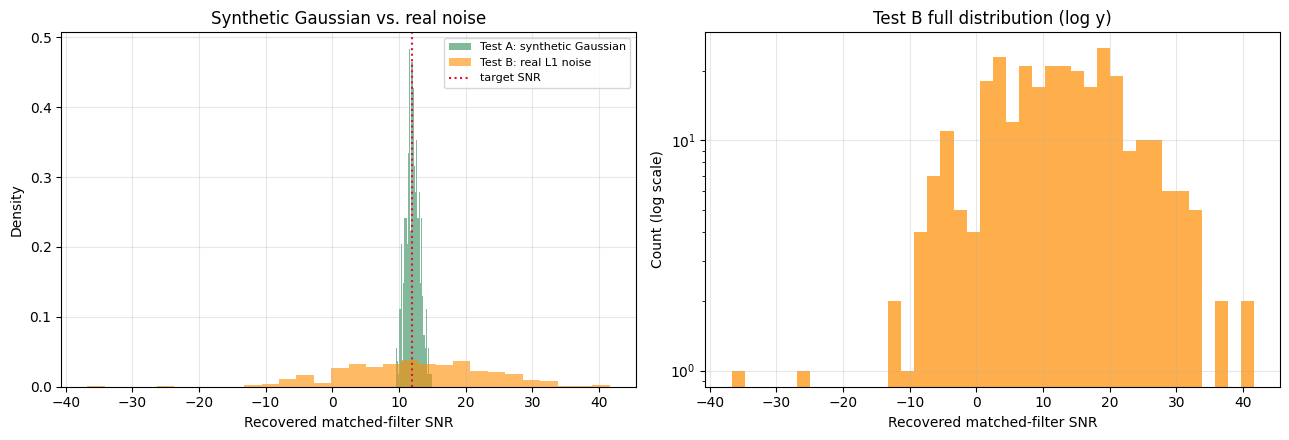


Real-noise recovery differs from the Gaussian reference: robust_std=11.54.


In [ ]:
# ---------------------------------------------------------------------------
# Test B: real LIGO noise recovery -- diagnostic, not a pass/fail gate
# ---------------------------------------------------------------------------
N_TRIALS_B = 300
recovered_real = []
pool = raw_noise_pools['calib_block']
for _ in range(N_TRIALS_B):
    start_idx = rng.integers(0, len(pool) - N_SAMPLES_WINDOW)
    noise_window = pool[start_idx: start_idx + N_SAMPLES_WINDOW].astype(np.float64)
    noise_window = noise_window - noise_window.mean()

    f_peak_trial = rng.uniform(1500.0, 4000.0)
    h_t = generate_signal(f_peak_trial, tau_test)
    h_scaled = scale_to_snr(h_t, TARGET_SNR)
    data_window = noise_window + h_scaled

    recovered_real.append(matched_filter_snr(data_window, h_scaled))

stats_B = recovery_trial_stats(recovered_real, TARGET_SNR)
print("=== Test B: real LIGO L1 noise (calib_block) ===")
print(f"Target SNR: {TARGET_SNR}")
print(f"mean={stats_B['mean']:.3f}  std={stats_B['std']:.3f}  median={stats_B['median']:.3f}  "
      f"robust_std={stats_B['robust_std']:.3f}")
print(f"quantiles: 1%={stats_B['q01']:.2f}  5%={stats_B['q05']:.2f}  50%={stats_B['q50']:.2f}  "
      f"95%={stats_B['q95']:.2f}  99%={stats_B['q99']:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(recovered_gaussian, bins=30, alpha=0.6, color='seagreen', density=True,
             label='Test A: synthetic Gaussian')
axes[0].hist(recovered_real, bins=30, alpha=0.6, color='darkorange', density=True,
             label='Test B: real L1 noise')
axes[0].axvline(TARGET_SNR, color='crimson', ls=':', label='target SNR')
axes[0].set_xlabel('Recovered matched-filter SNR'); axes[0].set_ylabel('Density')
axes[0].set_title('Synthetic Gaussian vs. real noise'); axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].hist(recovered_real, bins=40, alpha=0.7, color='darkorange', log=True)
axes[1].set_xlabel('Recovered matched-filter SNR'); axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Test B full distribution (log y)'); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'plot_testB_real_noise_diagnostic.pdf'))
plt.show()

if not (0.7 < stats_B['robust_std'] < 1.4):
    print(f"\nReal-noise recovery differs from the Gaussian reference: "
          f"robust_std={stats_B['robust_std']:.2f}.")
else:
    print("\nReal-noise recovery is close to the Gaussian reference in this sample.")


### Test C — injection/whitening path

Run `inject_and_whiten` directly on random signal parameters. Check that the output is finite, that
window variances remain bounded, and that the edge variance does not dominate the interior.


In [ ]:
# ---------------------------------------------------------------------------
# Test C: production-pipeline (inject_and_whiten) stability check
# ---------------------------------------------------------------------------
N_TRIALS_C = 200
edge_frac = int(0.05 * N_SAMPLES_WINDOW)

pipeline_windows = []
pipeline_variances = []
edge_vars, interior_vars = [], []
for _ in range(N_TRIALS_C):
    tau_c = rng.choice([0.001, 0.003, 0.005, 0.010, 0.020, 0.040])
    f_peak_c = rng.uniform(1500.0, 4000.0)
    snr_c = rng.uniform(8.0, 20.0)
    w, h_scaled, _ = inject_and_whiten('calib_block', f_peak=f_peak_c, tau=tau_c, target_snr=snr_c)
    pipeline_windows.append(w)
    pipeline_variances.append(np.var(w))
    edge_vars.append(np.var(np.concatenate([w[:edge_frac], w[-edge_frac:]])))
    interior_vars.append(np.var(w[edge_frac:-edge_frac]))

pipeline_windows = np.array(pipeline_windows)
pipeline_variances = np.array(pipeline_variances)
edge_vars, interior_vars = np.array(edge_vars), np.array(interior_vars)

print(f"=== Test C: inject_and_whiten stability ({N_TRIALS_C} trials) ===")
print(f"All finite: {np.all(np.isfinite(pipeline_windows))}")
print(f"Per-window variance: mean={pipeline_variances.mean():.1f}, std={pipeline_variances.std():.1f}, "
      f"min={pipeline_variances.min():.1f}, max={pipeline_variances.max():.1f}")
edge_ratio = edge_vars.mean() / interior_vars.mean()
print(f"Edge/interior variance ratio: {edge_ratio:.2f}")

assert np.all(np.isfinite(pipeline_windows)), "Test C: non-finite pipeline output."
assert edge_ratio < 3.0, (
    f"Test C: edge variance is {edge_ratio:.1f}x the interior variance; check padding and edge trim."
)
assert pipeline_variances.max() < 50 * np.median(pipeline_variances), (
    "Test C: at least one window has unusually large variance."
)
print("\nTest C passed.")


=== Test C: inject_and_whiten stability (200 trials) ===
All finite: True
Per-window variance: mean=6648.0, std=544.7, min=5563.0, max=8249.1
Edge/interior variance ratio: 2.04

Test C passed.


## 6. Edge check

Repeat the edge/interior variance comparison on a fresh set of injected windows.


In [ ]:
# ---------------------------------------------------------------------------
# 6. Edge-artifact check on injected windows
# ---------------------------------------------------------------------------
N_CHECK = 200
edge_frac = int(0.05 * N_SAMPLES_WINDOW)

edge_vars, interior_vars = [], []
for _ in range(N_CHECK):
    w, _, _ = inject_and_whiten('calib_block', f_peak=2500.0, tau=0.010, target_snr=12.0)
    edge_vars.append(np.var(np.concatenate([w[:edge_frac], w[-edge_frac:]])))
    interior_vars.append(np.var(w[edge_frac:-edge_frac]))

edge_vars, interior_vars = np.array(edge_vars), np.array(interior_vars)
ratio = edge_vars.mean() / interior_vars.mean()
print(f"Mean variance in edge 5% of window: {edge_vars.mean():.3f}")
print(f"Mean variance in interior 90%:      {interior_vars.mean():.3f}")
print(f"Edge/interior ratio: {ratio:.3f}")
assert ratio < 3.0, (
    f"Edge variance is {ratio:.1f}x the interior variance; check padding and edge trim."
)
print("Edge check passed.")


Mean variance in edge 5% of window: 10261.049
Mean variance in interior 90%:      5934.265
Edge/interior ratio: 1.729
Edge check passed.


## 7. Constant-Q transform

Compute a CQT magnitude map for each 100 ms whitened window. The frequency range is chosen to cover
the 1.5–4 kHz signal band while keeping the longest CQT kernels shorter than the analysis window.


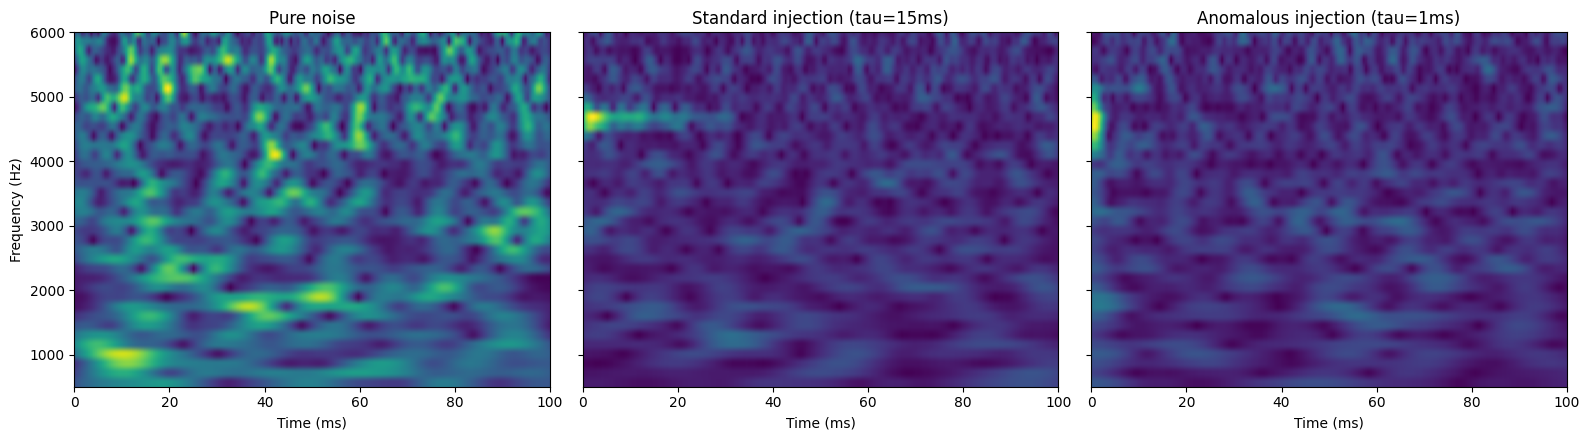

In [ ]:
# ---------------------------------------------------------------------------
# 7. CQT time-frequency representation
# ---------------------------------------------------------------------------
import librosa

# Starting at 500 Hz keeps the longest CQT kernel shorter than the 100 ms window
# while covering the 1.5–4 kHz signal band.
CQT_FMIN = 500.0
CQT_N_BINS = 48  # four octaves at 12 bins/octave
CQT_BINS_PER_OCTAVE = 12
CQT_HOP_LENGTH = 8

def compute_cqt(whitened_window, fs=FS, fmin=CQT_FMIN, n_bins=CQT_N_BINS,
                 bins_per_octave=CQT_BINS_PER_OCTAVE, hop_length=CQT_HOP_LENGTH):
    """Return the CQT magnitude of a whitened window."""
    C = librosa.cqt(whitened_window, sr=fs, fmin=fmin, n_bins=n_bins,
                     bins_per_octave=bins_per_octave, hop_length=hop_length)
    return np.abs(C)

# Noise and two example injections
noise_example, _ = make_noise_only_window('calib_block')
std_example, h_std, _ = inject_and_whiten('calib_block', f_peak=2500.0, tau=0.015, target_snr=15.0)
anom_example, h_anom, _ = inject_and_whiten('calib_block', f_peak=2500.0, tau=0.001, target_snr=15.0)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, (title, window) in zip(
        axes,
        [('Pure noise', noise_example), ('Standard injection (tau=15ms)', std_example),
         ('Anomalous injection (tau=1ms)', anom_example)]):
    cqt_mag = compute_cqt(window)
    freqs_cqt = librosa.cqt_frequencies(n_bins=cqt_mag.shape[0], fmin=CQT_FMIN,
                                         bins_per_octave=CQT_BINS_PER_OCTAVE)
    im = ax.imshow(cqt_mag, aspect='auto', origin='lower',
                    extent=[0, WINDOW_DUR * 1000, freqs_cqt[0], freqs_cqt[-1]],
                    cmap='viridis')
    ax.set_ylim(CQT_FMIN, min(F_HIGH, freqs_cqt[-1]))
    ax.set_xlabel('Time (ms)')
    ax.set_title(title)
axes[0].set_ylabel('Frequency (Hz)')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'plot_cqt_examples.pdf'))
plt.show()

## 8. Demonstration injection grid

Build a small grid over damping time and target SNR for inspection. Notebook 3 generates the larger
grid used for detectability calibration.


In [ ]:
# ---------------------------------------------------------------------------
# 8. Small demonstration grid
# ---------------------------------------------------------------------------
DEMO_TAU_GRID_MS = [1, 3, 5, 10, 20, 40]
DEMO_SNR_GRID = [8, 12, 16, 20]
DEMO_N_PER_CELL = 20  # demonstration only

demo_windows = {}
demo_meta = []
for tau_ms in DEMO_TAU_GRID_MS:
    for snr in DEMO_SNR_GRID:
        key = (tau_ms, snr)
        batch = []
        for _ in range(DEMO_N_PER_CELL):
            f_peak = rng.uniform(1500.0, 4000.0)
            w, h_scaled, _ = inject_and_whiten('calib_block', f_peak=f_peak, tau=tau_ms / 1000.0,
                                                target_snr=float(snr))
            batch.append(w)
            demo_meta.append({"tau_ms": tau_ms, "snr": snr, "f_peak": f_peak})
        demo_windows[key] = np.array(batch)

print(f"Built demo grid: {len(DEMO_TAU_GRID_MS)} tau values x {len(DEMO_SNR_GRID)} SNR values x "
      f"{DEMO_N_PER_CELL} samples = {len(DEMO_TAU_GRID_MS)*len(DEMO_SNR_GRID)*DEMO_N_PER_CELL} "
      f"injected windows")

np.savez(os.path.join(OUT_DIR, "demo_injection_grid.npz"),
         **{f"tau{k[0]}ms_snr{k[1]}": v for k, v in demo_windows.items()})
with open(os.path.join(OUT_DIR, "demo_injection_meta.json"), "w") as f:
    json.dump(demo_meta, f, indent=2)
print(f"Saved -> {OUT_DIR}/demo_injection_grid.npz, demo_injection_meta.json")


Built demo grid: 6 tau values x 4 SNR values x 20 samples = 480 injected windows
Saved -> /content/drive/MyDrive/gw_postmerger/nb2_artifacts/demo_injection_grid.npz, demo_injection_meta.json


## 9. Artifacts saved by this notebook

```text
nb2_artifacts/
  plot_testA_gaussian_snr_recovery.pdf
  plot_testB_real_noise_diagnostic.pdf
  plot_cqt_examples.pdf
  demo_injection_grid.npz
  demo_injection_meta.json
```

Notebook 3 uses the same injection and CQT setup to build the graph statistic and calibration grid.
